1. Create two CSV file with three columns viz. Tom, Brick, Harry with index ‘True’ and ‘False’.
Each column must contain at least ten values each as a combination of datatypes.
2. Create a data frame with at least 5 columns and 10 rows. There must be some missing
values in it. If the integer column contains missing values replace it with some statistical
approach. Also, if there is any missing values in String column, drop the rows using some
looping function.
3. Create a data frame with at least 5 columns and 10 rows. Each column must contain only
integer elements only. Column names must be Abilash, Ankit, Ashok, Asif, Anjaan. Now
apply a function where we want to club together the data based on any row or column.
Group the series using a mapper or by a series of columns.
4. Read the CountryDataIND.csv file and perform statistical operation on the same about the
dataset. Look for any missing data if any.
5. Plot a histogram by keeping the bin size to 10 for the column name = ‘Observation Value’.
Also Plot a scatter plot between ‘observation Value’ and ‘Time Period’

In [1]:
import numpy as np
import pandas as pd
data_true={'Tom': ['Apple', 10, 25.5, 'Banana', 12, np.nan, 'Cherry', 15, 30.0, 'Date'],
    'Brick': [100, 'Green', 200.5, 300, 'Blue', 400.7, 500, 'Red', 600.9, 700],
    'Harry': ['London', 90, 'Paris', 80, 70.2, 'Rome', 60, 55.0, 'Tokyo', 40]}
d_true=pd.DataFrame(data_true)
d_true.to_csv('Tom_Brick_Harry_True.csv', index=True)
data_false={'Tom': [20, 'Grape', 35.5, 'Kiwi', 42, 50.1, 'Mango', 55, 60.3, 'Orange'],
    'Brick': ['Yellow', 80, 75.2, 'Black', 65, 58.9, 'White', 50, 45.6, 'Pink'],
    'Harry': [30, 'Berlin', 25.0, 22, 'Cairo', 18.7, 15, 'Madrid', 10.9, 'Sydney']}
d_false=pd.DataFrame(data_false)
d_false.to_csv('Tom_Brick_Harry_False.csv', index=False)

In [3]:
missing_data={'ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', np.nan, 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'Age': [24, 27, np.nan, 32, 29, np.nan, 45, 38, 42, 35],
    'Score': [85, 91, np.nan, 78, 88, 76, 95, np.nan, 82, 90],
    'City': ['New York', 'Los Angeles', np.nan, 'Chicago', 'Boston', 'Houston', 'Miami', 'Dallas', 'Seattle', 'Denver']}
df=pd.DataFrame(missing_data)
mean_age=df['Age'].mean()
mean_score=df['Score'].mean()
df['Age']=df['Age'].fillna(mean_age)
df['Score']=df['Score'].fillna(mean_score)
#df['Age'].fillna(mean_age,inplace=True)
df['Name']=df['Name'].dropna()
for idx, row in df.iterrows():
    if pd.isna(row['Name']) or pd.isna(row['City']):
        df.drop(idx, inplace=True)

print(df)

   ID   Name   Age   Score         City
0   1  Alice  24.0  85.000     New York
1   2    Bob  27.0  91.000  Los Angeles
3   4  David  32.0  78.000      Chicago
5   6  Frank  34.0  76.000      Houston
6   7  Grace  45.0  95.000        Miami
7   8  Heidi  38.0  85.625       Dallas
8   9   Ivan  42.0  82.000      Seattle
9  10   Judy  35.0  90.000       Denver


In [29]:
data = {'Abilash': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'Ankit': [15, 25, 35, 45, 55, 65, 75, 85, 95, 105],
    'Ashok': [12, 22, 32, 42, 52, 62, 72, 82, 92, 102],
    'Asif': [18, 28, 38, 48, 58, 68, 78, 88, 98, 108],
    'Anjaan': [14, 24, 34, 44, 54, 64, 74, 84, 94, 104]}
df=pd.DataFrame(data)
print(df)
mapper = {'Abilash': 'Group2', 'Ankit': 'Group2', 'Ashok': 'Group3',
          'Asif': 'Group1', 'Anjaan': 'Group3'}
# grouped=df.groupby(mapper, axis=1).sum()
grouped = df.T.groupby(mapper).sum().T
print(grouped)
df['Category'] = ['Cat1', 'Cat1', 'Cat2', 'Cat2', 'Cat1', 'Cat2', 'Cat1', 'Cat2', 'Cat1', 'Cat2']
grouped_rows = df.groupby('Category').sum()
print(df)
print(grouped_rows)

   Abilash  Ankit  Ashok  Asif  Anjaan
0       10     15     12    18      14
1       20     25     22    28      24
2       30     35     32    38      34
3       40     45     42    48      44
4       50     55     52    58      54
5       60     65     62    68      64
6       70     75     72    78      74
7       80     85     82    88      84
8       90     95     92    98      94
9      100    105    102   108     104
   Group1  Group2  Group3
0      18      25      26
1      28      45      46
2      38      65      66
3      48      85      86
4      58     105     106
5      68     125     126
6      78     145     146
7      88     165     166
8      98     185     186
9     108     205     206
   Abilash  Ankit  Ashok  Asif  Anjaan Category
0       10     15     12    18      14     Cat1
1       20     25     22    28      24     Cat1
2       30     35     32    38      34     Cat2
3       40     45     42    48      44     Cat2
4       50     55     52    58      54     Ca

In [34]:
df=pd.read_csv('CountryDataIND.csv')
df=pd.DataFrame(df)
print(df['Observation Value'].mean())
print(df['Observation Value'].median())
print(df['Observation Value'].mode())
print(df.describe())
print(df.isnull().sum())

140.80689655172415
48.5
0       0.2
1       3.2
2       7.0
3      16.0
4      20.2
5      21.8
6      26.1
7      27.5
8      33.0
9      36.0
10     42.4
11     45.9
12     47.0
13     48.2
14     48.5
15     51.5
16     74.3
17     76.4
18     94.9
19    109.3
20    287.0
21    301.0
22    312.0
23    327.0
24    343.0
25    371.0
26    398.0
27    412.0
28    503.0
Name: Observation Value, dtype: float64
       Time period  Observation Value  Time period details  Footnotes
count    29.000000          29.000000            29.000000        0.0
mean   1999.551724         140.806897          1999.551724        NaN
std       4.807629         156.922569             4.807629        NaN
min    1990.000000           0.200000          1990.000000        NaN
25%    1998.000000          27.500000          1998.000000        NaN
50%    2000.000000          48.500000          2000.000000        NaN
75%    2004.000000         301.000000          2004.000000        NaN
max    2006.000000         5

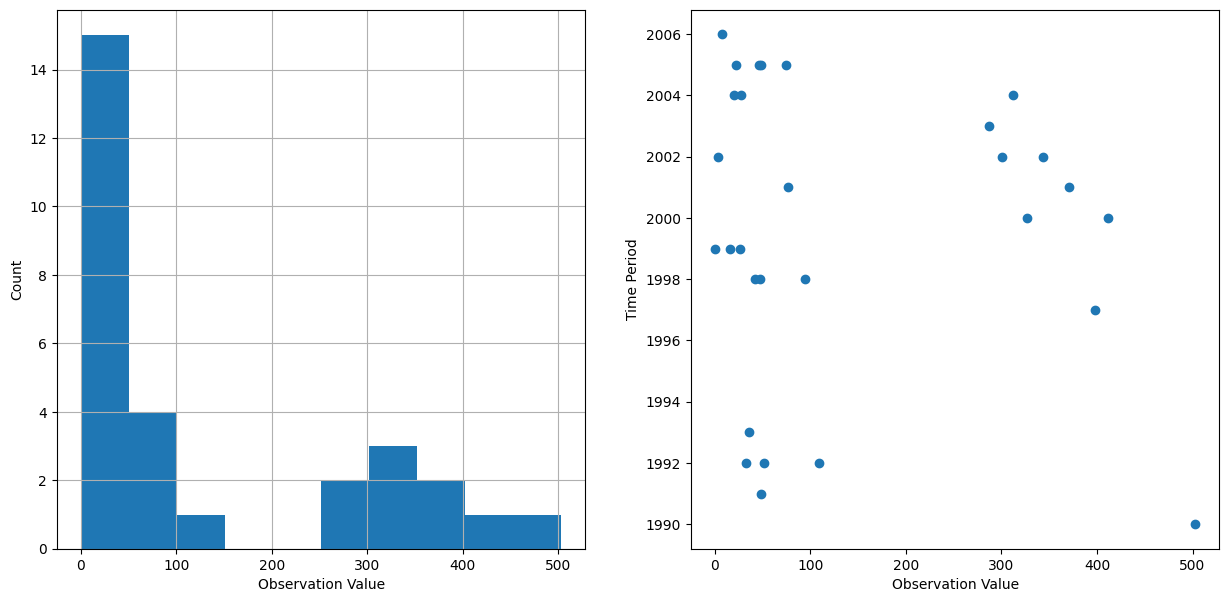

In [38]:
from matplotlib import pyplot as plt

plt.figure(figsize=[15,7])
plt.subplot(1,2,1)
df['Observation Value'].hist(bins=10)
plt.xlabel('Observation Value')
plt.ylabel('Count')

plt.subplot(1,2,2)
plt.scatter(df['Observation Value'], df['Time period'])
plt.xlabel('Observation Value')
plt.ylabel('Time Period')
plt.show()

Q2
Suppose you have landed to a job and the first task you’ve assigned to prepare a report which
includes the following:
1. Player Count
o Total Number of Players
2. Purchasing Analysis (Total)
o Number of Unique Items
o Average Purchase Price
o Total Number of Purchases
o Total Revenue
3. Gender Demographics
o Percentage and Count of Male Players
o Percentage and Count of Female Players
o Percentage and Count of Other / Non-Disclosed
4. Purchasing Analysis (Gender)
o The below each broken by gender
 Purchase Count
 Average Purchase Price
 Total Purchase Value
 Average Purchase Total per Person by Gender

5. Age Demographics
o The below each broken into bins of 4 years (i.e. <10, 10-14, 15-19, etc.)
 Purchase Count
 Average Purchase Price
 Total Purchase Value
 Average Purchase Total per Person by Age Group

6. Top Spenders
o Identify the the top 5 spenders in the game by total purchase value, then list (in a
table):

 SN
 Purchase Count
 Average Purchase Price
 Total Purchase Value

7. Most Popular Items
o Identify the 5 most popular items by purchase count, then list (in a table):
 Item ID
 Item Name
 Purchase Count
 Item Price
 Total Purchase Value

8. Most Profitable Items
o the 5 most profitable items by total purchase value, then list (in a table):
 Item ID
 Item Name
 Purchase Count
 Item Price
 Total Purchase Value

In [39]:
np.random.seed(42)

# Generate player data
num_players = 100
num_purchases = 300

players = pd.DataFrame({
    'SN': [f'Player{i}' for i in range(num_players)],
    'Gender': np.random.choice(['Male', 'Female', 'Other/Non-Disclosed'], num_players, p=[0.6, 0.3, 0.1]),
    'Age': np.random.randint(7, 45, num_players)
})

# Generate item data
num_items = 50
items = pd.DataFrame({
    'Item ID': range(num_items),
    'Item Name': [f'Item_{i}' for i in range(num_items)],
    'Item Price': np.round(np.random.uniform(1.0, 10.0, num_items), 2)
})

# Generate purchase data
purchases = pd.DataFrame({
    'Purchase ID': range(num_purchases),
    'SN': np.random.choice(players['SN'], num_purchases),
    'Item ID': np.random.choice(items['Item ID'], num_purchases),
    'Age': np.random.randint(7, 45, num_purchases),
    'Gender': np.random.choice(['Male', 'Female', 'Other/Non-Disclosed'], num_purchases, p=[0.6, 0.3, 0.1])
})

# Merge with item prices
purchases = purchases.merge(items[['Item ID', 'Item Name', 'Item Price']], on='Item ID')

print("Players DataFrame:")
print(players.head())
print("\nItems DataFrame:")
print(items.head())
print("\nPurchases DataFrame:")
print(purchases.head())

# Save to CSV
purchases.to_csv('purchases.csv', index=False)
players.to_csv('players.csv', index=False)
items.to_csv('items.csv', index=False)

Players DataFrame:
        SN               Gender  Age
0  Player0                 Male   38
1  Player1  Other/Non-Disclosed   38
2  Player2               Female   10
3  Player3                 Male   36
4  Player4                 Male   43

Items DataFrame:
   Item ID Item Name  Item Price
0        0    Item_0        6.02
1        1    Item_1        8.94
2        2    Item_2        2.70
3        3    Item_3        3.51
4        4    Item_4        7.30

Purchases DataFrame:
   Purchase ID        SN  Item ID  Age  Gender Item Name  Item Price
0            0  Player45        4   41    Male    Item_4        7.30
1            1   Player5       28   21  Female   Item_28        7.49
2            2  Player98       36   31    Male   Item_36        5.38
3            3  Player36       37   43    Male   Item_37        9.15
4            4  Player23       18   34    Male   Item_18        3.75


In [52]:
purchases['Gender'].value_counts()

Gender
Male                   170
Female                 100
Other/Non-Disclosed     30
Name: count, dtype: int64

In [65]:
print(f'Total Players count is {len(players)}')
print(f'Number of unique items is {len(set(items['Item ID']))}')
print(f'Average Purchase price is {purchases['Item Price'].mean()}')
print(f'Total number of purchases is {len(purchases)}')
print(f'Total Revenue is {purchases["Item Price"].sum()}')
print(f'Percentage and Count of Male Players is {players['Gender'].value_counts(normalize=True).get('Male', 0)} and {players['Gender'].value_counts().get('Male', 0)}')
print(f'Percentage and Count of Female Players is {players['Gender'].value_counts(normalize=True).get('Female', 0)} and {players['Gender'].value_counts().get('Female', 0)}')
print(f'Percentage and Count of Other/Non-Disclosed Players is {players['Gender'].value_counts(normalize=True).get('Other/Non-Disclosed', 0)} and {players['Gender'].value_counts().get('Other/Non-Disclosed', 0)}')
print(f'Gender-Wise Purchase Counts are: \n{purchases.groupby("Gender")['Gender'].value_counts()}')
print(f'Gender-Wise Average Prices are: \n{purchases.groupby('Gender')['Item Price'].mean()}')
print(f'Gender-Wise Total Purchase Values are: \n{purchases.groupby("Gender")['Item Price'].sum()}')
print('')

Total Players count is 100
Number of unique items is 50
Average Purchase price is 6.1453999999999995
Total number of purchases is 300
Total Revenue is 1843.62
Percentage and Count of Male Players is 0.63 and 63
Percentage and Count of Female Players is 0.28 and 28
Percentage and Count of Other/Non-Disclosed Players is 0.09 and 9
Gender-Wise Purchase Counts are: 
Gender
Female                 100
Male                   170
Other/Non-Disclosed     30
Name: count, dtype: int64
Gender-Wise Average Prices are: 
Gender
Female                 6.190600
Male                   6.054647
Other/Non-Disclosed    6.509000
Name: Item Price, dtype: float64
Gender-Wise Total Purchase Values are: 
Gender
Female                  619.06
Male                   1029.29
Other/Non-Disclosed     195.27
Name: Item Price, dtype: float64
